[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch03.ipynb)

Notebook Bab 3 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Skala fitur numerik memengaruhi model berbasis jarak (k-NN, SVM), tetapi tidak model berbasis pohon. Di sini kita mengukur efeknya pada data yang sama.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, QuantileTransformer, RobustScaler, StandardScaler

RANDOM_STATE = 42
print('Setup selesai.')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


Setup selesai.


## Section 1 - Demo: Transformasi Numerik pada Online News Popularity


## Data nyata: fitur numerik artikel berita daring


In [2]:
DATA_DIR = section_data_dir('ch03_online_news_popularity')
df = pd.read_parquet(DATA_DIR / 'online_news_popularity.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

feature_cols = [c for c in df.columns if c not in ['url', 'timedelta', 'shares']]
shape_feature = 'kw_avg_avg'
boundary_features = ['num_hrefs', 'kw_avg_avg']

print('Snapshot:', DATA_DIR / 'online_news_popularity.parquet')
print(f"Baris: {stats['rows']:,} | Fitur prediktif numerik: {stats['predictive_feature_count']} | Missing cells: {stats['missing_cells']}")
print(f"Target shares: median={stats['shares_median']:,.0f}, max={stats['shares_max']:,}, skew={stats['shares_skew']:.3f}, IQR outliers={stats['shares_iqr_outliers']:,}")
print('Catatan:', stats['source_page_rows_note'])

range_table = pd.DataFrame(stats['feature_range_examples']).T[['min', 'max', 'range']]
print('\nContoh rentang fitur terbesar:')
print(range_table.head(8).round(3).to_string())

print(f"\nFitur bentuk distribusi `{shape_feature}`: min={df[shape_feature].min():.3f}, median={df[shape_feature].median():.3f}, max={df[shape_feature].max():.3f}, skew={df[shape_feature].skew():.3f}")


Snapshot: data\section1\ch03_online_news_popularity\online_news_popularity.parquet
Baris: 39,644 | Fitur prediktif numerik: 58 | Missing cells: 0
Target shares: median=1,400, max=843,300, skew=33.964, IQR outliers=4,541
Catatan: UCI web metadata currently displays 39,797 instances, while the downloaded CSV contains 39,644 data rows.

Contoh rentang fitur terbesar:
                            min       max     range
kw_avg_max                  0.0  843300.0  843300.0
kw_min_max                  0.0  843300.0  843300.0
kw_max_max                  0.0  843300.0  843300.0
self_reference_avg_sharess  0.0  843300.0  843300.0
self_reference_max_shares   0.0  843300.0  843300.0
self_reference_min_shares   0.0  843300.0  843300.0
kw_max_avg                  0.0  298400.0  298400.0
kw_max_min                  0.0  298400.0  298400.0

Fitur bentuk distribusi `kw_avg_avg`: min=0.000, median=2870.075, max=43567.660, skew=5.760


## Distribusi, transformasi bentuk, dan fixed ruler


               model   representasi  RMSE_log1p_shares
                k-NN            raw             0.9083
                k-NN StandardScaler             0.8894
HistGradientBoosting            raw             0.8494
HistGradientBoosting StandardScaler             0.8494


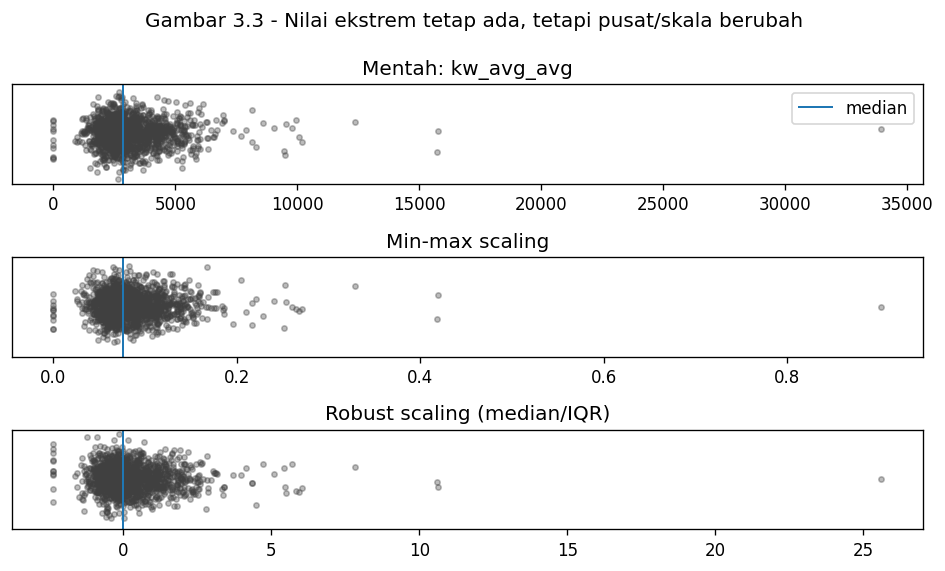

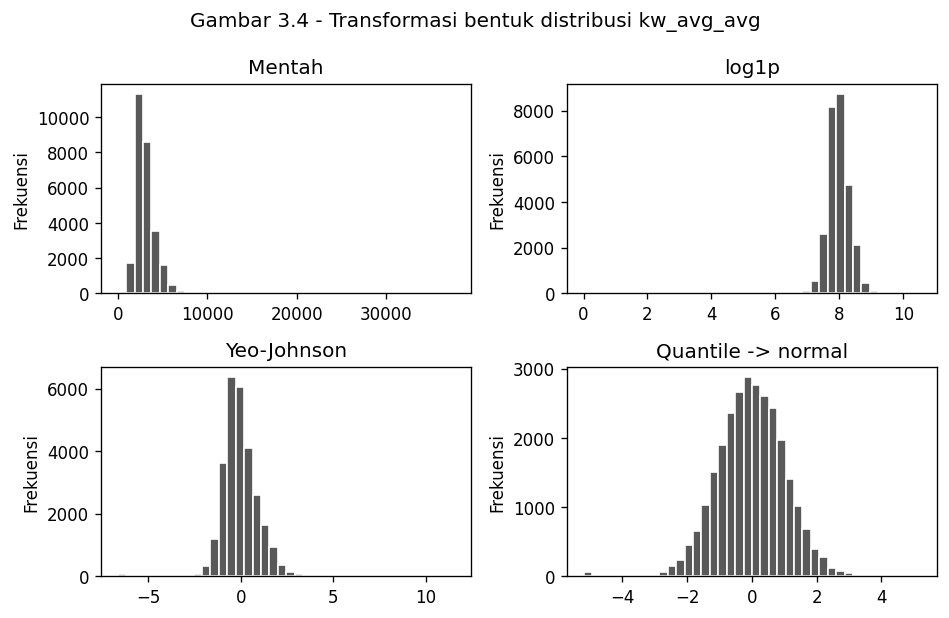

In [3]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)

# Gambar 3.3: min-max vs robust scaling pada fitur yang berekor kanan.
values = train_df[[shape_feature]].to_numpy()
minmax_values = MinMaxScaler().fit_transform(values).ravel()
robust_values = RobustScaler().fit_transform(values).ravel()
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(values), size=1600, replace=False)

fig, axes = plt.subplots(3, 1, figsize=(8, 4.8), sharey=True)
for ax, arr, title in [
    (axes[0], values.ravel(), f'Mentah: {shape_feature}'),
    (axes[1], minmax_values, 'Min-max scaling'),
    (axes[2], robust_values, 'Robust scaling (median/IQR)'),
]:
    y_jitter = rng.normal(0, 0.025, size=len(sample_idx))
    ax.scatter(arr[sample_idx], y_jitter, s=10, alpha=0.35, color='0.25')
    ax.axvline(np.median(arr), color='tab:blue', lw=1.2, label='median')
    ax.set_title(title)
    ax.set_yticks([])
axes[0].legend(loc='upper right')
fig.suptitle('Gambar 3.3 - Nilai ekstrem tetap ada, tetapi pusat/skala berubah')
plt.tight_layout()

# Gambar 3.4: transformasi bentuk distribusi pada fitur prediktif real.
feature_train = train_df[[shape_feature]]
shape_views = {
    'Mentah': feature_train[shape_feature].to_numpy(),
    'log1p': np.log1p(feature_train[shape_feature].to_numpy()),
    'Yeo-Johnson': PowerTransformer(method='yeo-johnson').fit_transform(feature_train).ravel(),
    'Quantile -> normal': QuantileTransformer(
        n_quantiles=min(1000, len(feature_train)),
        output_distribution='normal',
        random_state=RANDOM_STATE,
    ).fit_transform(feature_train).ravel(),
}
fig, axes = plt.subplots(2, 2, figsize=(8, 5.2))
for ax, (name, arr) in zip(axes.ravel(), shape_views.items()):
    ax.hist(arr, bins=40, color='0.35', edgecolor='white')
    ax.set_title(name)
    ax.set_ylabel('Frekuensi')
fig.suptitle(f'Gambar 3.4 - Transformasi bentuk distribusi {shape_feature}')
plt.tight_layout()

# Fixed ruler: model sama, representasi berubah.
X_train, X_test = train_df[feature_cols], test_df[feature_cols]
y_train, y_test = np.log1p(train_df['shares']), np.log1p(test_df['shares'])

def rmse(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

results = pd.DataFrame([
    {'model': 'k-NN', 'representasi': 'raw', 'RMSE_log1p_shares': rmse(KNeighborsRegressor(n_neighbors=25))},
    {'model': 'k-NN', 'representasi': 'StandardScaler', 'RMSE_log1p_shares': rmse(Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=25))]))},
    {'model': 'HistGradientBoosting', 'representasi': 'raw', 'RMSE_log1p_shares': rmse(HistGradientBoostingRegressor(max_iter=120, learning_rate=0.06, random_state=RANDOM_STATE))},
    {'model': 'HistGradientBoosting', 'representasi': 'StandardScaler', 'RMSE_log1p_shares': rmse(Pipeline([('scaler', StandardScaler()), ('model', HistGradientBoostingRegressor(max_iter=120, learning_rate=0.06, random_state=RANDOM_STATE))]))},
])
print(results.round(4).to_string(index=False))


Akurasi ilustratif raw=0.743; scaled=0.746


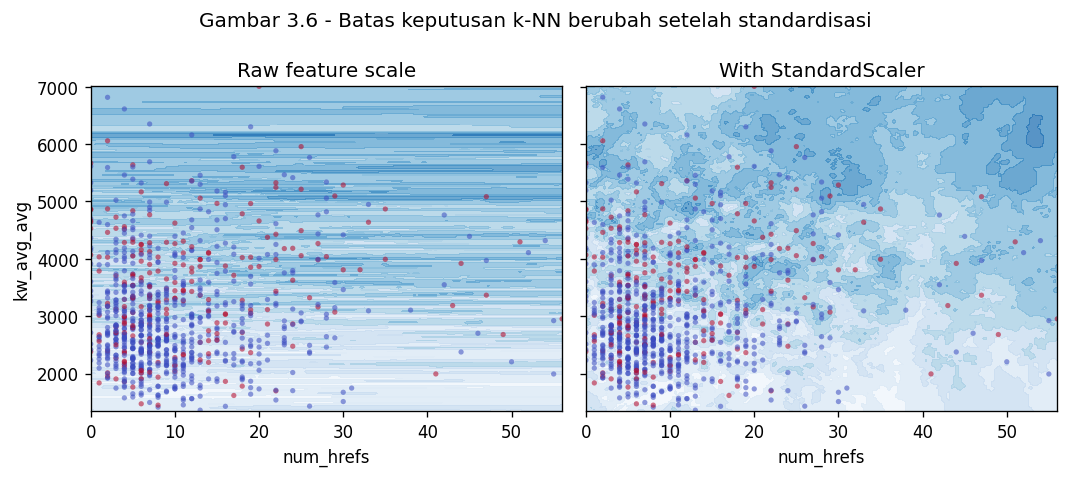

In [4]:
# Gambar 3.6: batas keputusan k-NN pada dua fitur real dari Online News Popularity.
y_high = (df['shares'] >= df['shares'].quantile(0.75)).astype(int)
X2 = df[boundary_features]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y_high, test_size=0.30, stratify=y_high, random_state=RANDOM_STATE
)

raw_clf = KNeighborsClassifier(n_neighbors=35).fit(X2_train, y2_train)
scaled_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=35)),
]).fit(X2_train, y2_train)

# Plot the central feature range so the boundary is readable despite heavy tails.
x_min, x_max = X2['num_hrefs'].quantile([0.01, 0.99])
y_min, y_max = X2['kw_avg_avg'].quantile([0.01, 0.99])
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 180), np.linspace(y_min, y_max, 180))
grid = pd.DataFrame({'num_hrefs': xx.ravel(), 'kw_avg_avg': yy.ravel()})

plot_rows = X2_test[
    X2_test['num_hrefs'].between(x_min, x_max) & X2_test['kw_avg_avg'].between(y_min, y_max)
].sample(900, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, model, title in [
    (axes[0], raw_clf, 'Raw feature scale'),
    (axes[1], scaled_clf, 'With StandardScaler'),
]:
    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap='Blues', alpha=0.75)
    ax.scatter(
        plot_rows['num_hrefs'], plot_rows['kw_avg_avg'],
        c=y2_test.loc[plot_rows.index], cmap='coolwarm', s=10, alpha=0.55, edgecolor='none'
    )
    ax.set_title(title)
    ax.set_xlabel('num_hrefs')
axes[0].set_ylabel('kw_avg_avg')
fig.suptitle('Gambar 3.6 - Batas keputusan k-NN berubah setelah standardisasi')
plt.tight_layout()

print(f"Akurasi ilustratif raw={raw_clf.score(X2_test, y2_test):.3f}; scaled={scaled_clf.score(X2_test, y2_test):.3f}")


> 🔎 **Amati.** Online News memuat fitur numerik dengan rentang yang sangat berbeda: sebagian berupa hitungan, sebagian berupa statistik popularitas historis, dan sebagian berupa rasio 0..1. Fitur `kw_avg_avg` berekor kanan, sehingga log, Yeo-Johnson, dan quantile transform mengubah bentuk distribusinya, bukan sekadar satuan sumbu. Pada fixed ruler, standardisasi menurunkan RMSE k-NN pada target `log1p(shares)`, sedangkan model pohon boosting jauh lebih stabil terhadap scaling linear.


## Section 2 - Mini Project

## Soal

Anda diberi data numerik dengan distribusi menceng dan skala antar-kolom yang timpang. Bangun *pipeline* yang menerapkan transformasi yang sesuai (misalnya *power transform* untuk kolom menceng dan *scaling* untuk penyeragaman rentang), lalu bandingkan satu model berbasis jarak dengan satu model berbasis pohon.

**Luaran:** kode *pipeline*, akurasi CV kedua model, dan 2-3 kalimat analisis kapan transformasi membantu.

**Kriteria penilaian:** (a) transformasi berada di dalam *pipeline*; (b) minimal dua keluarga model dibandingkan; (c) analisis menghubungkan hasil dengan sifat model.


In [5]:
# DATA AWAL (jangan diubah) - fitur menceng dan multi-skala.
Xr, yr = make_classification(n_samples=1200, n_features=6, n_informative=4,
                             n_redundant=0, random_state=7)
Xr[:, 1] = np.exp(Xr[:, 1])        # kolom menceng
Xr[:, 3] = Xr[:, 3] * 800          # kolom skala besar
Xr[:, 5] = np.abs(Xr[:, 5]) ** 3   # ekor panjang
print('Data:', Xr.shape, '| target seimbang:', np.bincount(yr))


Data: (1200, 6) | target seimbang: [598 602]


In [6]:
# Kerjakan di sini.
# Petunjuk: sklearn.preprocessing.PowerTransformer + StandardScaler di dalam Pipeline.
